# NB08 — Skenario C: FQA + Enhancement + Re-clustering (versi single-variable)

**Perbaikan metodologi.** Versi sebelumnya terkonfound: jalur embedding Skenario C
berbeda dari Skenario A (re-deteksi `det_thresh` beda, `warp512`→512→112, matching
bbox pada foto grup). Akibatnya A vs C mengubah banyak variabel sekaligus.

**Prinsip versi ini:** Skenario C berbeda dari A **hanya pada SATU variabel = enhancement**.
- Wajah yang **tidak** dienhance → memakai embedding Skenario A yang **identik** (di-copy).
- Hanya wajah yang **benar-benar dienhance** yang di-embed ulang, pada kanvas
  **112×112 `norm_crop`** (geometri identik dengan InsightFace `face.normed_embedding`).
- Landmark (`kps`) diambil dari metadata NB01 (sudah disimpan) → **tanpa re-deteksi**.

**Prasyarat:** NB01 sudah di-re-run dengan `kps` tersimpan di `metadata.pkl`.

**Runtime:** GPU untuk ArcFace (hanya subset yang dienhance di-embed ulang → cepat).

In [1]:
# Cell 1 — Install (mirror NB01 yang sudah terbukti jalan di Colab)
!pip install -q insightface opencv-python-headless pillow tqdm hdbscan scikit-learn
!pip install -q onnxruntime-gpu==1.19.0
try:
    import faiss
    print("faiss OK:", faiss.__version__)
except ImportError:
    !pip install -q faiss-gpu
    import faiss

faiss OK: 1.14.3


In [2]:
# Cell 2 — Imports & Mount
import os, pickle, time, math, warnings
from pathlib import Path
from collections import defaultdict, Counter

import cv2
import numpy as np
import pandas as pd
import faiss
import matplotlib.pyplot as plt

import insightface
from insightface.app import FaceAnalysis
from insightface.utils import face_align

import hdbscan
from hdbscan.validity import validity_index
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix,
)

warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive', force_remount=True)
print('Drive mounted.')

Mounted at /content/drive
Drive mounted.


In [3]:
# Cell 3 — Config
BASE       = Path("/content/drive/MyDrive/OTW S.KOM/Embeddings")
NB01_DIR   = BASE / "output_nb01"
NB06_DIR   = BASE / "output_nb06"
NB07_DIR   = BASE / "output_nb07"
LABEL_DIR  = BASE / "output_labeling"
OUTPUT_DIR = BASE / "output_nb08"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

VARLAP_REF   = 300.0
NOISE_REF    = 15.0
ILLUM_SIGMA  = 50.0
CONTRAST_REF = 60.0
ARCFACE_SIZE = 112

HDBSCAN_MCS = 50
HDBSCAN_MS  = 5

SUBSAMPLE   = 2000
RANDOM_SEED = 42

print('Config OK. Output:', OUTPUT_DIR)

Config OK. Output: /content/drive/MyDrive/OTW S.KOM/Embeddings/output_nb08


In [4]:
# Cell 4 — Fungsi FQA + Enhancement + norm_crop
def immerkaer_sigma(gray):
    H, W = gray.shape
    if H < 2 or W < 2:
        return 0.0
    kernel = np.array([[1, -2, 1], [-2, 4, -2], [1, -2, 1]], dtype=np.float64)
    resp = cv2.filter2D(gray.astype(np.float64), -1, kernel)
    return np.sqrt(np.abs(resp).sum() * math.pi / (6 * (H - 2) * (W - 2)) + 1e-9)


def compute_sub_scores(native_bgr, bbox, kps):
    gray = cv2.cvtColor(native_bgr, cv2.COLOR_BGR2GRAY)
    var_lap = cv2.Laplacian(gray, cv2.CV_64F).var()
    blur_s  = float(np.clip(var_lap / VARLAP_REF, 0, 1))
    bw, bh  = bbox[2] - bbox[0], bbox[3] - bbox[1]
    res_s   = float(np.clip(min(bw, bh) / 112.0, 0, 1))
    mean_b       = float(gray.mean())
    illum_mean_s = float(math.exp(-((mean_b - 128.0) ** 2) / (2 * ILLUM_SIGMA ** 2)))
    contrast_s   = float(np.clip(gray.std() / CONTRAST_REF, 0, 1))
    sigma   = immerkaer_sigma(gray)
    noise_s = float(np.clip(1.0 - sigma / NOISE_REF, 0, 1))
    if kps is not None:
        le, re, nose = kps[0], kps[1], kps[2]
        d_l = abs(nose[0] - le[0])
        d_r = abs(re[0] - nose[0])
        yaw = min(d_l, d_r) / max(d_l, d_r) if max(d_l, d_r) > 0 else 0.0
    else:
        yaw = None
    return {
        "blur": blur_s, "resolution": res_s,
        "illumination": 0.5 * illum_mean_s + 0.5 * contrast_s,
        "noise": noise_s, "pose": yaw,
        "_mean_brightness_raw": mean_b,
        "_contrast_score": contrast_s,
        "_illum_mean_s": illum_mean_s,
    }


def norm_crop_interp(img_full, kps, image_size=112, cubic=False):
    M = face_align.estimate_norm(np.array(kps, dtype=np.float32), image_size=image_size)
    flag = cv2.INTER_CUBIC if cubic else cv2.INTER_LINEAR
    return cv2.warpAffine(img_full, M, (image_size, image_size),
                          flags=flag, borderValue=0.0)


def apply_nlm_denoising(img):
    # window diskalakan turun untuk kanvas 112px (parameter asli 512px terlalu agresif)
    return cv2.fastNlMeansDenoisingColored(img, None, 5, 5, 5, 15)

def apply_gamma_correction(img, mean_raw):
    m     = float(np.clip(mean_raw / 255.0, 1e-3, 0.999))
    gamma = float(np.clip(math.log(0.5) / math.log(m), 0.4, 2.5))
    lut   = np.array([((i / 255.0) ** (1.0 / gamma)) * 255
                       for i in range(256)]).astype("uint8")
    return cv2.LUT(img, lut)

def apply_clahe(img):
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    l   = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(2, 2)).apply(l)  # (8,8) di 512px = tile 64px; (2,2) di 112px ≈ tile 56px
    return cv2.cvtColor(cv2.merge((l, a, b)), cv2.COLOR_LAB2BGR)

def apply_laplacian_sharpening(img):
    k = np.array([[0, -1, 0], [-1, 5, -1], [0, -1, 0]], dtype=np.float32)
    return cv2.filter2D(img, -1, k)

print('Fungsi FQA + norm_crop + enhancement terdefinisi.')

Fungsi FQA + norm_crop + enhancement terdefinisi.


In [5]:
# Cell 5 — Load recognition model + threshold theta dari NB07
app = FaceAnalysis(name="buffalo_l", allowed_modules=["detection", "recognition"])
app.prepare(ctx_id=0)
rec_model = app.models["recognition"]
print("Recognition model siap. Providers:", rec_model.session.get_providers())

with open(NB07_DIR / "skenario_b_results.pkl", "rb") as f:
    nb07 = pickle.load(f)
th = {sc: float(v["theta"]) for sc, v in nb07["thresholds"].items()}
if "resolution" not in th:
    th["resolution"] = 0.7
    print("resolution tidak ada di NB07 -> fallback theta=0.7")

print("\nThreshold theta (dari Youden J NB07):")
for sc, v in th.items():
    print(f"  {sc:15s} theta = {v:.3f}")

Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecutionProvider': {'sdpa_kernel': '0', 'use_tf32': '1', 'prefer_nhwc': '0', 'tunable_op_max_tuning_duration_ms': '0', 'enable_skip_layer_norm_strict_mode': '0', 'tunable_op_tuning_enable': '0', 'tunable_op_enable': '0', 'use_ep_level_unified_stream': '0', 'device_id': '0', 'has_user_compute_stream': '0', 'gpu_external_empty_cache': '0', 'cudnn_conv_algo_search': 'EXHAUSTIVE', 'cudnn_conv1d_pad_to_nc1d': '0', 'gpu_mem_limit': '18446744073709551615', 'gpu_external_alloc': '0', 'gpu_external_free': '0', 'arena_extend_strategy': 'kNextPowerOfTwo', 'do_copy_in_default_stream': '1', 'enable_cuda_graph': '0', 'user_compute_stream': '0', 'cudnn_conv_use_max_workspace': '1'}}
model ignore: /root/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68
Applied providers: ['CUDAExecutionProvider', 'CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}, 'CUDAExecution

In [6]:
# Cell 6 — Load embedding A + metadata (dengan kps) + ground-truth
A_embeddings = np.load(NB01_DIR / "embeddings.npy").astype(np.float32)
N = A_embeddings.shape[0]

with open(NB01_DIR / "metadata.pkl", "rb") as f:
    meta = pickle.load(f)

assert len(meta) == N, f"Mismatch: {len(meta)} meta vs {N} embeddings"
assert "kps" in meta[0], "NB01 BELUM di-re-run dengan kps! Jalankan NB01 dulu."

df_gt = pd.read_csv(LABEL_DIR / "face_labels_verified.csv")
assert len(df_gt) == N, f"Mismatch ground-truth: {len(df_gt)} vs {N}"

print(f"Embedding A : {A_embeddings.shape}")
print(f"Metadata    : {N} records (kps tersedia)")
print(f"Ground-truth: {len(df_gt)} baris, {df_gt['identity_id'].max()+1} identitas")

Embedding A : (15248, 512)
Metadata    : 15248 records (kps tersedia)
Ground-truth: 15248 baris, 75 identitas


In [7]:
# Cell 7 — VALIDASI PIPELINE (versi hemat RAM — foto dimuat satu per satu, tidak di-cache semua)
rng = np.random.default_rng(RANDOM_SEED)
sample_gi = rng.choice(N, size=min(200, N), replace=False)

sample_photo_to_gi = defaultdict(list)
for gi in sample_gi:
    sample_photo_to_gi[meta[gi]["photo_path"]].append(gi)

cos_sims = []
for photo_path, gis in sample_photo_to_gi.items():
    img = cv2.imread(str(photo_path))
    if img is None:
        continue
    for gi in gis:
        m = meta[gi]
        aligned = norm_crop_interp(img, m["kps"], ARCFACE_SIZE, cubic=False)
        emb = rec_model.get_feat(aligned).flatten().astype(np.float32)
        emb /= (np.linalg.norm(emb) + 1e-9)
        cos_sims.append(float(np.dot(emb, A_embeddings[gi])))
    del img

cos_sims = np.array(cos_sims)
print(f"Cosine similarity (re-embed tanpa enhancement) vs Skenario A, n={len(cos_sims)}:")
print(f"  mean = {cos_sims.mean():.5f}")
print(f"  min  = {cos_sims.min():.5f}")
print(f"  p05  = {np.percentile(cos_sims, 5):.5f}")

if cos_sims.mean() > 0.999:
    print("\nGATE LULUS - jalur re-embedding identik dengan Skenario A. Lanjut.")
else:
    print("\nGATE GAGAL - ada perbedaan preprocessing. JANGAN lanjut sebelum diperbaiki.")

Cosine similarity (re-embed tanpa enhancement) vs Skenario A, n=194:
  mean = 1.00000
  min  = 1.00000
  p05  = 1.00000

GATE LULUS - jalur re-embedding identik dengan Skenario A. Lanjut.


In [8]:
# Cell 8 — Loop utama: enhancement SELEKTIF
new_embeddings = A_embeddings.copy()   # un-enhanced IDENTIK dengan Skenario A
n_enhanced = 0
n_skip_img = 0
tech_count = Counter()

photo_to_indices = defaultdict(list)
for gi, m in enumerate(meta):
    photo_to_indices[m["photo_path"]].append(gi)

t0 = time.time()
print(f"Memproses {len(photo_to_indices):,} foto ({N:,} wajah)...")

for idx_ph, (photo_path, indices) in enumerate(photo_to_indices.items()):
    if idx_ph % 100 == 0:
        print(f"  [{idx_ph:4d}/{len(photo_to_indices)}]  enhanced={n_enhanced}  t={time.time()-t0:.0f}s", end="\r")
    img = cv2.imread(str(photo_path))
    if img is None:
        n_skip_img += len(indices)
        continue

    for gi in indices:
        m = meta[gi]
        bbox = m["bbox"]
        kps  = m["kps"]
        x1, y1, x2, y2 = [int(v) for v in bbox]
        native = img[max(0, y1):y2, max(0, x1):x2]
        if native.size == 0:
            continue

        fqa = compute_sub_scores(native, bbox, kps)

        need_sr      = fqa["resolution"]      < th.get("resolution", 0.7)
        need_denoise = fqa["noise"]           < th.get("noise", 0.6)
        need_gamma   = fqa["_illum_mean_s"]   < th.get("illumination", 0.7)
        need_clahe   = fqa["_contrast_score"] < th.get("illumination", 0.7)
        need_sharpen = fqa["blur"]            < th.get("blur", 0.6)

        if not (need_sr or need_denoise or need_gamma or need_clahe or need_sharpen):
            continue

        work = norm_crop_interp(img, kps, ARCFACE_SIZE, cubic=need_sr)
        applied = []
        if need_sr:      applied.append("sr")
        if need_denoise: work = apply_nlm_denoising(work);           applied.append("denoise")
        if need_gamma:   work = apply_gamma_correction(work, fqa["_mean_brightness_raw"]); applied.append("gamma")
        if need_clahe:   work = apply_clahe(work);                   applied.append("clahe")
        if need_sharpen: work = apply_laplacian_sharpening(work);    applied.append("sharpen")

        emb = rec_model.get_feat(work).flatten().astype(np.float32)
        new_embeddings[gi] = emb / (np.linalg.norm(emb) + 1e-9)
        n_enhanced += 1
        for t in applied:
            tech_count[t] += 1

elapsed = time.time() - t0
print(f"\nSelesai dalam {elapsed:.1f}s ({elapsed/60:.1f} menit)")
print(f"  Wajah dienhance : {n_enhanced:,} / {N:,} ({n_enhanced/N*100:.1f}%)")
print(f"  Foto tak terbaca: {n_skip_img:,} wajah (tetap pakai embedding A)")
print(f"  Teknik (frekuensi): {dict(tech_count.most_common())}")

changed = int((np.abs(new_embeddings - A_embeddings).sum(axis=1) > 1e-6).sum())
print(f"  Embedding berubah dari A: {changed:,} (harus = n_enhanced = {n_enhanced})")

np.save(OUTPUT_DIR / "embeddings_enhanced.npy", new_embeddings)
print(f"Tersimpan: output_nb08/embeddings_enhanced.npy {new_embeddings.shape}")

Memproses 2,435 foto (15,248 wajah)...

Selesai dalam 2742.9s (45.7 menit)
  Wajah dienhance : 11,907 / 15,248 (78.1%)
  Foto tak terbaca: 1,234 wajah (tetap pakai embedding A)
  Teknik (frekuensi): {'clahe': 7197, 'gamma': 5269, 'denoise': 5038, 'sr': 2931, 'sharpen': 1846}
  Embedding berubah dari A: 11,907 (harus = n_enhanced = 11907)
Tersimpan: output_nb08/embeddings_enhanced.npy (15248, 512)


In [9]:
# Cell 9 — HDBSCAN re-clustering (params IDENTIK NB05)
print(f"HDBSCAN mcs={HDBSCAN_MCS}, ms={HDBSCAN_MS}, method=eom, metric=euclidean")
t0 = time.time()
clusterer_c = hdbscan.HDBSCAN(
    min_cluster_size=HDBSCAN_MCS,
    min_samples=HDBSCAN_MS,
    cluster_selection_method="eom",
    metric="euclidean",
    core_dist_n_jobs=-1,
)
labels_c = clusterer_c.fit_predict(new_embeddings)

n_clusters_c  = int(labels_c.max() + 1) if labels_c.max() >= 0 else 0
n_noise_c     = int((labels_c == -1).sum())
n_clustered_c = int((labels_c >= 0).sum())
noise_pct_c   = n_noise_c / N * 100
coverage_c    = n_clustered_c / N * 100
sizes_c = sorted(Counter(labels_c[labels_c >= 0].tolist()).values(), reverse=True)

print(f"\nSkenario C: {n_clusters_c} cluster, coverage {coverage_c:.2f}%, noise {noise_pct_c:.2f}%")
print(f"  Ukuran cluster: min={min(sizes_c)}, max={max(sizes_c)}, mean={np.mean(sizes_c):.1f}")
print(f"  Waktu HDBSCAN : {time.time()-t0:.1f}s")

HDBSCAN mcs=50, ms=5, method=eom, metric=euclidean

Skenario C: 68 cluster, coverage 70.99%, noise 29.01%
  Ukuran cluster: min=50, max=1689, mean=159.2
  Waktu HDBSCAN : 256.1s


In [10]:
# Cell 10 — Metrik internal (Silhouette, DBCV, DBI) — metodologi identik NB06
D = new_embeddings.shape[1]
rng      = np.random.default_rng(seed=RANDOM_SEED)
idx_pool = np.where(labels_c >= 0)[0]
n_sub    = min(SUBSAMPLE, len(idx_pool))
idx_sub  = np.sort(rng.choice(idx_pool, size=n_sub, replace=False))

emb_sub = new_embeddings[idx_sub].copy().astype(np.float32)
faiss.normalize_L2(emb_sub)

print(f"Silhouette (n_sub={n_sub})...")
try:
    res   = faiss.StandardGpuResources()
    index = faiss.index_cpu_to_gpu(res, 0, faiss.IndexFlatIP(D))
except Exception:
    index = faiss.IndexFlatIP(D)
index.add(emb_sub)
sim_matrix, _ = index.search(emb_sub, n_sub)
dist_matrix   = np.clip(1.0 - sim_matrix.astype(np.float64), 0.0, 2.0)
np.fill_diagonal(dist_matrix, 0.0)

labels_sub  = labels_c[idx_sub]
sil_score_c = silhouette_score(dist_matrix, labels_sub, metric='precomputed')
print(f"  Silhouette = {sil_score_c:.4f}")

mask_valid   = labels_sub >= 0
dist_sub     = dist_matrix[np.ix_(mask_valid, mask_valid)]
labels_valid = labels_sub[mask_valid]
valid_clusters = {lbl for lbl, cnt in Counter(labels_valid.tolist()).items() if cnt >= 3}
keep         = np.isin(labels_valid, list(valid_clusters))
dist_sub_v   = dist_sub[np.ix_(keep, keep)]
labels_v     = labels_valid[keep]
remap        = {old: new for new, old in enumerate(np.unique(labels_v))}
labels_v_remap = np.array([remap[l] for l in labels_v])
try:
    dbcv_score_c = validity_index(dist_sub_v, labels_v_remap, metric='precomputed', d=D)
    print(f"  DBCV = {dbcv_score_c:.4f}")
except AssertionError as e:
    dbcv_score_c = float('nan')
    print(f"  DBCV gagal (hdbscan bug): {e}")

dbi_score_c = davies_bouldin_score(emb_sub[mask_valid].astype(np.float64), labels_valid)
print(f"  DBI = {dbi_score_c:.4f}")

Silhouette (n_sub=2000)...
  Silhouette = -0.0747
  DBCV gagal (hdbscan bug): 
  DBI = 1.6466


In [11]:
# Cell 11 — Metrik eksternal (Purity, ARI, NMI) — identik NB06, hanya identity_id >= 0
def purity_score(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return float(cm.max(axis=0).sum() / cm.sum())

df_gt["cluster_c"] = df_gt["global_index"].map(dict(zip(range(N), labels_c)))
df_eval = df_gt[df_gt["identity_id"] >= 0].copy()
y_true  = df_eval["identity_id"].values
y_pred  = df_eval["cluster_c"].values

purity_c = purity_score(y_true, y_pred)
ari_c    = adjusted_rand_score(y_true, y_pred)
nmi_c    = normalized_mutual_info_score(y_true, y_pred, average_method='arithmetic')

print(f"Wajah dievaluasi: {len(df_eval):,}  |  identitas unik: {len(np.unique(y_true))}")
print(f"Purity = {purity_c:.4f}")
print(f"ARI    = {ari_c:.4f}")
print(f"NMI    = {nmi_c:.4f}")

Wajah dievaluasi: 10,174  |  identitas unik: 75
Purity = 0.8878
ARI    = 0.6509
NMI    = 0.9081


  PERBANDINGAN SKENARIO A vs C


Skenario,A — Baseline,C — FQA+Enhance
coverage_pct,74.6131,70.9864
noise_pct,25.3869,29.0136
n_clusters,72,68
silhouette,-0.1019,-0.0747
dbcv,None,None
dbi,1.5617,1.6466
purity,0.9894,0.8878
ari,0.9943,0.6509
nmi,0.9973,0.9081



Delta C vs A (+ = C lebih baik):
  coverage_pct  : -3.6267  tidak
  noise_pct     : +3.6267  tidak
  silhouette    : +0.0272  ya
  dbcv          : NaN
  dbi           : +0.0849  tidak
  purity        : -0.1016  tidak
  ari           : -0.3434  tidak
  nmi           : -0.0892  tidak


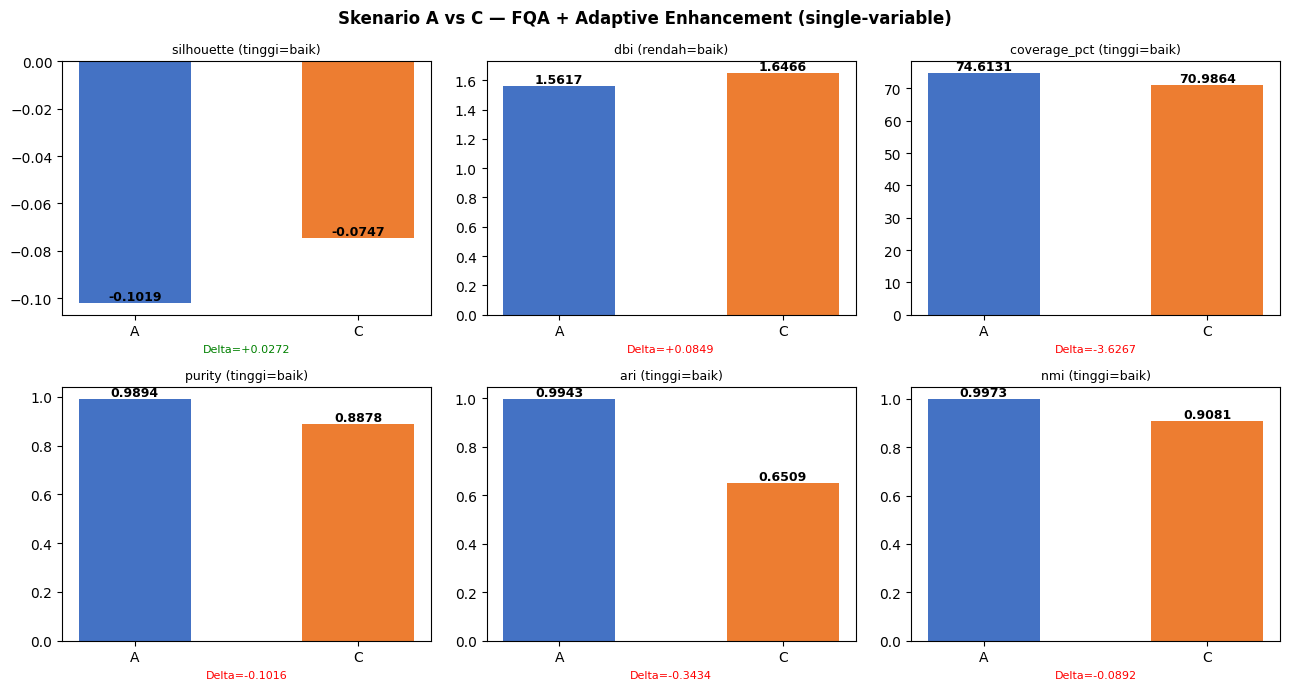


Tersimpan: skenario_c_results.pkl, perbandingan_a_vs_c.csv, perbandingan_a_vs_c.png
n_enhanced = 11907/15248 (78.1%)  teknik={'gamma': 5269, 'clahe': 7197, 'denoise': 5038, 'sr': 2931, 'sharpen': 1846}


In [12]:
# Cell 12 — Tabel & bar chart perbandingan A vs C + simpan output
with open(NB06_DIR / "skenario_a_results.pkl", "rb") as f:
    sa = pickle.load(f)

metrics_internal_c = {
    "coverage_pct": round(coverage_c, 4),
    "noise_pct"   : round(noise_pct_c, 4),
    "n_clusters"  : n_clusters_c,
    "silhouette"  : round(float(sil_score_c), 4),
    "dbcv"        : round(float(dbcv_score_c), 4) if not np.isnan(dbcv_score_c) else None,
    "dbi"         : round(float(dbi_score_c), 4),
}
metrics_external_c = {
    "purity": round(purity_c, 4),
    "ari"   : round(ari_c, 4),
    "nmi"   : round(nmi_c, 4),
}

df_compare = pd.DataFrame([
    {"Skenario": "A — Baseline",     **sa["metrics_internal"], **sa["metrics_external"]},
    {"Skenario": "C — FQA+Enhance",  **metrics_internal_c,     **metrics_external_c},
])
print("=" * 70)
print("  PERBANDINGAN SKENARIO A vs C")
print("=" * 70)
display(df_compare.set_index("Skenario").T)

lower_better = {"noise_pct", "dbi"}
print("\nDelta C vs A (+ = C lebih baik):")
for c in df_compare.columns:
    if c in ("Skenario", "n_clusters"):
        continue
    va, vc = df_compare.loc[0, c], df_compare.loc[1, c]
    if va is None or vc is None:
        print(f"  {c:14s}: NaN")
        continue
    delta = vc - va
    good  = (delta < 0) if c in lower_better else (delta > 0)
    print(f"  {c:14s}: {delta:+.4f}  {'ya' if good else 'tidak'}")

plots = [("silhouette", True), ("dbi", False), ("coverage_pct", True),
         ("purity", True), ("ari", True), ("nmi", True)]
fig, axes = plt.subplots(2, 3, figsize=(13, 7)); axes = axes.flatten()
for ax, (key, higher_better) in zip(axes, plots):
    va = sa["metrics_internal"].get(key, sa["metrics_external"].get(key))
    vc = metrics_internal_c.get(key, metrics_external_c.get(key))
    bars = ax.bar(["A", "C"], [va or 0, vc or 0], color=["#4472C4", "#ED7D31"], width=0.5)
    for bar, val in zip(bars, [va, vc]):
        if val is not None:
            ax.text(bar.get_x()+bar.get_width()/2, bar.get_height(), f"{val:.4f}",
                    ha='center', va='bottom', fontsize=9, fontweight='bold')
    d = (vc - va) if (va is not None and vc is not None) else None
    good = None if d is None else ((d < 0) if not higher_better else (d > 0))
    note = "tinggi=baik" if higher_better else "rendah=baik"
    ax.set_title(f"{key} ({note})", fontsize=9)
    if d is not None:
        ax.set_xlabel(f"Delta={d:+.4f}", fontsize=8, color='green' if good else 'red')
plt.suptitle("Skenario A vs C — FQA + Adaptive Enhancement (single-variable)", fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "perbandingan_a_vs_c.png", dpi=150, bbox_inches='tight')
plt.show()

skenario_c = {
    "skenario": "C",
    "deskripsi": "FQA + Adaptive Enhancement (single-variable, enhance di norm_crop 112)",
    "dataset": {
        "n_total": N, "n_clustered": n_clustered_c, "n_noise": n_noise_c,
        "n_enhanced": n_enhanced, "n_verified": int(len(df_eval)),
        "n_identities": int(len(np.unique(y_true))), "tech_count": dict(tech_count),
    },
    "params": {"min_cluster_size": HDBSCAN_MCS, "min_samples": HDBSCAN_MS,
               "cluster_selection_method": "eom", "metric": "euclidean"},
    "thresholds_used": th,
    "metrics_internal": metrics_internal_c,
    "metrics_external": metrics_external_c,
}
with open(OUTPUT_DIR / "skenario_c_results.pkl", "wb") as f:
    pickle.dump(skenario_c, f)
df_compare.to_csv(OUTPUT_DIR / "perbandingan_a_vs_c.csv", index=False)
print("\nTersimpan: skenario_c_results.pkl, perbandingan_a_vs_c.csv, perbandingan_a_vs_c.png")
print(f"n_enhanced = {n_enhanced}/{N} ({n_enhanced/N*100:.1f}%)  teknik={dict(tech_count)}")